Loading balanced datasets...
SVM expects 100 features.
Loading pretrained models...
Training standalone Random Forest model...


[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done 100 out of 100 | elapsed:    0.0s finished


Hybrid - Accuracy: 0.9328
LightGBM - Accuracy: 0.8570
SVM - Accuracy: 0.8902
Random Forest - Accuracy: 0.8458


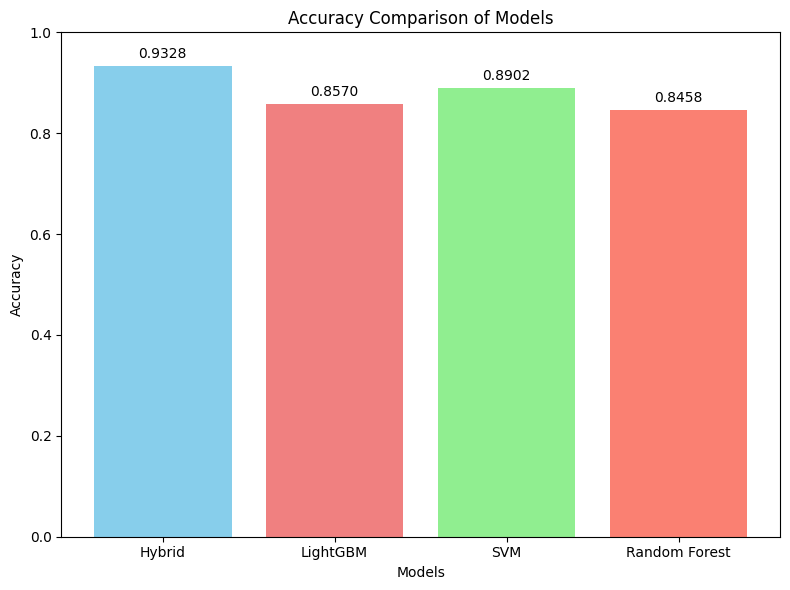

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import joblib
import matplotlib.pyplot as plt

# Load balanced datasets
print("Loading balanced datasets...")
X_balanced = pd.read_csv('balanced_X.csv')  # Features for LightGBM
y_balanced = pd.read_csv('balanced_y.csv').values.ravel()  # Target, flattened to 1D
X_ohe_balanced = np.load('balanced_X_ohe.npy')  # One-hot encoded features for SVM
y_ohe_balanced = np.load('balanced_y_ohe.npy')  # Target for SVM (assuming same as y_balanced)

# Verify SVM expected features
expected_features = X_ohe_balanced.shape[1]  # Number of features SVM expects (100)
print(f"SVM expects {expected_features} features.")

# Split into 90% training and 10% test sets
X_train_full, X_test, y_train_full, y_test = train_test_split(X_balanced, y_balanced, test_size=0.1, random_state=42)
X_ohe_train_full, X_ohe_test, y_ohe_train_full, y_ohe_test = train_test_split(X_ohe_balanced, y_ohe_balanced, test_size=0.1, random_state=42)

# Further split the 90% training into 80% train and 20% mixed test (for hybrid model evaluation)
X_train, X_mixed_test, y_train, y_mixed_test = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)
X_ohe_train, X_ohe_mixed_test, y_ohe_train, y_ohe_mixed_test = train_test_split(X_ohe_train_full, y_ohe_train_full, test_size=0.2, random_state=42)

# Align X_ohe_mixed_test and X_ohe_test with training features
def align_features(X_ohe, expected_features):
    if X_ohe.shape[1] != expected_features:
        X_ohe_aligned = np.zeros((X_ohe.shape[0], expected_features))
        min_features = min(X_ohe.shape[1], expected_features)
        X_ohe_aligned[:, :min_features] = X_ohe[:, :min_features]
        return X_ohe_aligned
    return X_ohe

X_ohe_mixed_test_aligned = align_features(X_ohe_mixed_test, expected_features)
X_ohe_test_aligned = align_features(X_ohe_test, expected_features)

# Load pretrained models
print("Loading pretrained models...")
lgb_model = lgb.Booster(model_file='lgb_model.txt')  # LightGBM model
svm_model = joblib.load('svm_model.pkl')  # SVM model
meta_model = joblib.load('rf_meta_model.pkl')  # Random Forest meta-model

# Train a standalone Random Forest model
print("Training standalone Random Forest model...")
rf_model = RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42)
rf_model.fit(X_ohe_train, y_ohe_train)

# Evaluate models
accuracies = {}

# Hybrid model (on mixed test data)
lgb_pred = lgb_model.predict(X_mixed_test)
svm_pred = svm_model.predict_proba(X_ohe_mixed_test_aligned)
stacked = np.hstack([lgb_pred, svm_pred])
pred = meta_model.predict(stacked)
acc = accuracy_score(y_mixed_test, pred)
accuracies['Hybrid'] = acc
print(f"Hybrid - Accuracy: {acc:.4f}")

# LightGBM (on test data)
pred = np.argmax(lgb_model.predict(X_test), axis=1)  # LightGBM outputs probabilities
acc = accuracy_score(y_test, pred)
accuracies['LightGBM'] = acc
print(f"LightGBM - Accuracy: {acc:.4f}")

# SVM (on test data)
pred = svm_model.predict(X_ohe_test_aligned)
acc = accuracy_score(y_ohe_test, pred)
accuracies['SVM'] = acc
print(f"SVM - Accuracy: {acc:.4f}")

# Random Forest (on test data)
pred = rf_model.predict(X_ohe_test_aligned)
acc = accuracy_score(y_ohe_test, pred)
accuracies['Random Forest'] = acc
print(f"Random Forest - Accuracy: {acc:.4f}")

# Plotting the comparison graph
model_names = ['Hybrid', 'LightGBM', 'SVM', 'Random Forest']
acc_values = [accuracies[name] for name in model_names]

plt.figure(figsize=(8, 6))
bars = plt.bar(model_names, acc_values, color=['skyblue', 'lightcoral', 'lightgreen', 'salmon'])

# Add accuracy values on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom')

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Models')
plt.ylim(0, 1)  # Set y-axis limit to 0-1 for accuracy
plt.tight_layout()
plt.savefig('model_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()